In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import csv
from matplotlib import pyplot as plt
import pandas as pd
from pathlib import Path
import torch
from torchvision import datasets, transforms
from tqdm import tqdm
import numpy as np
import random
from collections import defaultdict
from matplotlib.patches import Patch
from scipy import stats
import re


import src.architectures.networkArchitectures as netArch # Assuming this is where your registry code lives
from src.robustness.general_classes import ModelBridge
from src.robustness.milp_functions import *
from src.architectures.networkArchitectures import networkRegistry
from src.robustness.exactRobustness import exactRobustness
from src.robustness.fastLin import fastLin
from src.testing.networkTesting import testNetwork
from src.training.networkTraining import trainNetwork, saveNetwork
from src.utils.extractParams import extractParams
from src.utils.loadNetwork import loadNetwork

In [2]:
classes_to_generate = (0, 1, 3)
som_modes = ["second place relative", "mean relative", "independent"]

# 🧪 Experiment 2 — Robustness of generated samples

**Goal:**

Learn about the robustness of selectiv-output-maximization generated samples.

---

### Setup

- `som_modes`: possible selective input maximization criterion

---

### Procedure

1. **Generate samples**

   For each (network,class,som_mode) there exists a unique image.
   Here we generate every possible such image using exact optimization,
   there will be (number of networks)x(number of classes we generate for)x(number of nodes)=40x3x3=360 such images. However, some might time out so the actual number will likely be fewer. 

2. **Fast-Lin test**
   - Test all generated images with all the networks.

3. **Exact test**
   - Tests `num_total_samples_to_test` samples.

   It is not feasible to test all the samples with all the networks. Instead we here take `num_total_samples_to_test` randomomly selected (network,generated image) pairs and tests them exactly. 
   
4. **Data analysis** (not yet done)
   - Plot histogram of the robustness results per class (exact and fastlin) and compare them to
   the results on MNIST
   - Analyze if perhaps an image generated by network A is more robust on A then on the other networks. To what extent does it generalize?
   - Analyze how the robustness (as tested on all networks) of a generated sample depends on network architecture (number of neurons, layers)

---

## Generate images

In [ ]:
# Something weird happens for Dense3x50 (for example)

# Where to save results
images_dir = Path("generated_images/Exp2GeneratedImages/")
results_dir = Path("results/")
images_dir.mkdir(exist_ok=True)
results_dir.mkdir(exist_ok=True)

csv_path = results_dir / "Exp2GenerationResults.csv"

# Load existing results to skip duplicates
computed_keys = set()
if csv_path.exists():
    with csv_path.open(mode="r") as f:
        reader = csv.reader(f)
        next(reader, None)  # Skip header
        for row in reader:
            if row:
                # Key: network-class-optimization
                computed_keys.add(f"{row[0]}-{row[1]}-{row[2]}")

with csv_path.open(mode="a", newline="") as file:
    writer = csv.writer(file)
    if csv_path.stat().st_size == 0:
        writer.writerow(["network", "class", "som_mode", "obj_val"])

    for networkName in netArch.networkRegistry.keys():
        print(f"\n--- Initializing Network Template: {networkName} ---")
        
        # Load the network 
        NetworkClass = netArch.networkRegistry[networkName].NetworkClass
        model_pt = NetworkClass()
        model_pt.load_state_dict(torch.load(f'networks/{networkName}.pth', map_location='cpu'))
        model_pt.eval()
        
        # Setup bridge
        bridge = ModelBridge(model_pt)
        bridge.load_layers_from_pytorch_model(L0=0, U0=1, input_shape=(784,))
        bridge.setup_gurobi_logic()
        
        template_model = bridge.gurobi_model 

        for cls in classes_to_generate:
            for opt_type in som_modes:
                
                # Check for existing work
                unique_key = f"{networkName}-{cls}-{opt_type}"
                if unique_key in computed_keys:
                    print(f"  [Skipping] {unique_key} already exists.")
                    continue
                print(f"  Generating: {networkName} | Class: {cls} | Mode: {opt_type}")
                
                sample_model = template_model.copy()
                
                try:
                    img, obj_val = feature_selection(bridge, cls, g_model=sample_model, mode=opt_type)
                    
                    if img is not None:
                        # Save the image to /generated_images/Exp2GeneratedImages
                        img_filename = f"{networkName}_{cls}_{opt_type.replace(' ', '_')}.png"
                        plt.imsave(images_dir / img_filename, img.reshape(28, 28), cmap='gray')
                        
                        # Save metadata to /results/Exp2GenerationResults.csv
                        writer.writerow([networkName, cls, opt_type, obj_val])
                        file.flush()
                
                except Exception as e:
                    print(f"  [Error] Failed to generate {unique_key}: {e}")
                
                finally:
                    sample_model.dispose()


--- Initializing Network Template: Dense1x60 ---
Set parameter Username
Set parameter LicenseID to value 2785972


Academic license - for non-commercial use only - expires 2027-03-02
Set parameter TimeLimit to value 90
  [Skipping] Dense1x60-0-second place relative already exists.
  [Skipping] Dense1x60-0-mean relative already exists.
  [Skipping] Dense1x60-0-independent already exists.
  [Skipping] Dense1x60-1-second place relative already exists.
  [Skipping] Dense1x60-1-mean relative already exists.
  [Skipping] Dense1x60-1-independent already exists.
  [Skipping] Dense1x60-3-second place relative already exists.
  [Skipping] Dense1x60-3-mean relative already exists.
  [Skipping] Dense1x60-3-independent already exists.

--- Initializing Network Template: Dense2x30 ---
Set parameter Username
Set parameter LicenseID to value 2785972
Academic license - for non-commercial use only - expires 2027-03-02
Set parameter TimeLimit to value 90
  [Skipping] Dense2x30-0-second place relative already exists.
  [Skipping] Dense2x30-0-mean relative already exists.
  [Skipping] Dense2x30-0-independent already ex

## Test generated images with Fast-lin

In [3]:
# Tests all the generated images with all the networks with Fast-Lin

images_dir = Path("generated_images/Exp2GeneratedImages")
results_dir = Path("results/")
results_dir.mkdir(exist_ok=True)
filePath = results_dir / "Exp2FastLinOnGeneratedSamples.csv"
pNorm = 1  # Don't change

# Load already completed results to enable skipping
computed_tests = set()
if filePath.exists():
    with filePath.open(mode="r") as f:
        reader = csv.reader(f)
        next(reader, None)
        for row in reader:
            if row:
                computed_tests.add((row[0], row[5]))

file_is_new = not filePath.exists() or filePath.stat().st_size == 0
with filePath.open(mode="a", newline="") as file:
    writer = csv.writer(file)
    
    if file_is_new:
        writer.writerow([
            "testing_network", "generating_network", "target_class", 
            "som_mode", "predicted_class", "filename", "fastlin_eps"
        ])

    # Get all generated images
    image_files = [f for f in os.listdir(images_dir) if f.endswith(".png")]

    for networkName in netArch.networkRegistry.keys():
        print(f"\n--- Testing on Network: {networkName} ---")
        
        # Load and prepare the testing network
        NetworkClass = netArch.networkRegistry[networkName].NetworkClass
        test_net = NetworkClass()
        test_net.load_state_dict(torch.load(f'networks/{networkName}.pth', map_location='cpu'))
        test_net.eval()
        params = extractParams(network=test_net, inputShape=(1, 28, 28))
        weights = [W for W, _ in params]
        biases = [b for _, b in params]

        for img_name in tqdm(image_files, desc=f"Processing images for {networkName}"):
            # Skip if this specific test has already been recorded
            if (networkName, img_name) in computed_tests:
                continue

            try:
                # Parse metadata from filename: [Net]_[Class]_[OptType].png
                parts = img_name.replace(".png", "").split("_")
                gen_net = parts[0]
                gen_cls = parts[1]
                opt_type = "_".join(parts[2:])

                # Load Image
                img_path = images_dir / img_name
                raw_img = plt.imread(img_path)

                # Handle multi-channel PNGs (take only the first channel)
                if raw_img.ndim == 3:
                    # If the image has channels (H, W, C), take the first one
                    x0 = raw_img[:, :, 0].flatten().astype(np.float32)
                else:
                    # If it's already (H, W)
                    x0 = raw_img.flatten().astype(np.float32)

                # Get Testing Network's Prediction
                img_torch = torch.from_numpy(x0).unsqueeze(0)

                with torch.no_grad():
                    output = test_net(img_torch)
                    _, predictedClass = torch.max(output, 1)
                    predictedClass = predictedClass.item()

                # Run Fast-Lin
                # targetClasses are all classes EXCEPT the one the network currently predicts
                targetClasses = [c for c in range(10) if c != predictedClass]
                
                certifiedEpsilon, _, _ = fastLin(
                    weights=weights, 
                    biases=biases, 
                    x0=x0, 
                    pNorm=pNorm, 
                    epsilon0=10, 
                    originalClass=predictedClass, 
                    targetClasses=targetClasses, 
                    tolerance=0.005
                )

                # Save Result
                writer.writerow([
                    networkName, gen_net, gen_cls, 
                    opt_type, predictedClass, img_name, certifiedEpsilon
                ])
                file.flush()

            except Exception as e:
                print(f"  [Error] Failed testing {img_name} on {networkName}: {e}")

print(f"\nEvaluation complete. Results saved to: {filePath}")


--- Testing on Network: Dense1x60 ---


Processing images for Dense1x60:   0%|          | 0/260 [00:00<?, ?it/s]

Processing images for Dense1x60: 100%|██████████| 260/260 [00:29<00:00,  8.89it/s]



--- Testing on Network: Dense2x30 ---


Processing images for Dense2x30: 100%|██████████| 260/260 [00:40<00:00,  6.45it/s]


...


--- Testing on Network: Dense2x32 ---


Processing images for Dense2x32: 100%|██████████| 260/260 [00:39<00:00,  6.58it/s]



--- Testing on Network: Dense3x48 ---


Processing images for Dense3x48: 100%|██████████| 260/260 [01:02<00:00,  4.18it/s]


Evaluation complete. Results saved to: results\Exp2FastLinOnGeneratedSamples.csv


## Tests subset of generated images exactly

In [3]:
# --- Configuration ---
num_total_samples_to_test = 230 
images_dir = Path("generated_images/Exp2GeneratedImages/")
results_dir = Path("results/")
filePath = results_dir / "Exp2ExactOnGeneratedSamples.csv"
pNorm = 1 

# Load already computed results to avoid duplicates
computed_tests = set()
if filePath.exists():
    with filePath.open(mode="r") as f:
        reader = csv.reader(f)
        next(reader, None)
        for row in reader:
            if row:
                computed_tests.add((row[0], row[5])) # (testing_network, filename)

# Identify all possible valid pairs
all_gen_files = [f for f in os.listdir(images_dir) if f.endswith(".png")]
all_networks = list(netArch.networkRegistry.keys())

# Create a list of every (net, img) combo we haven't done yet
potential_pairs = [
    (net, img) for net in all_networks for img in all_gen_files 
    if (net, img) not in computed_tests
]

# Randomly select the global subset
if not potential_pairs:
    print("No new tests to perform!")
else:
    to_test = random.sample(potential_pairs, min(num_total_samples_to_test, len(potential_pairs)))
    
    # 4. Group by network to avoid reloading models/tightening repeatedly
    tasks_by_net = defaultdict(list)
    for net, img in to_test:
        tasks_by_net[net].append(img)

    # 5. Execute Tests
    file_is_new = not filePath.exists() or filePath.stat().st_size == 0
    with filePath.open(mode="a", newline="") as file:
        writer = csv.writer(file)
        if file_is_new:
            writer.writerow(["testing_network", "generating_network", "target_class", 
                             "som_mode", "predicted_class", "filename", "epsilon"])

        for networkName, images_to_run in tasks_by_net.items():
            print(f"\n--- Initializing Network: {networkName} ({len(images_to_run)} samples) ---")
            
            # Load & Setup Network
            NetworkClass = netArch.networkRegistry[networkName].NetworkClass
            model_pt = NetworkClass()
            model_pt.load_state_dict(torch.load(f'networks/{networkName}.pth', map_location='cpu'))
            model_pt.eval()
            
            bridge = ModelBridge(model_pt)
            bridge.load_layers_from_pytorch_model(L0=0, U0=1, input_shape=(784,))
            bridge.layers[0].do_exact_bound_tightening() 
            bridge.setup_gurobi_logic()
            template_model = bridge.gurobi_model 

            for img_name in tqdm(images_to_run):
                try:
                    # A. Parse Metadata
                    parts = img_name.replace(".png", "").split("_")
                    gen_net, gen_cls = parts[0], int(parts[1])
                    opt_type = "_".join(parts[2:])

                    # B. Load Image & Handle Channels
                    raw_img = plt.imread(images_dir / img_name)
                    if raw_img.ndim == 3:
                        # Extract first channel only (converts RGBA/RGB to Grayscale)
                        img_np = raw_img[:, :, 0].flatten().astype(np.float32)
                    else:
                        img_np = raw_img.flatten().astype(np.float32)

                    # C. Predict
                    img_torch = torch.from_numpy(img_np).unsqueeze(0)
                    with torch.no_grad():
                        output = model_pt(img_torch)
                        predicted_class = int(torch.argmax(output, dim=1).item())

                    # D. Run MILP on copy
                    sample_model = template_model.copy()
                    robustness_setup(img_np, gen_cls, bridge, g_model=sample_model, max_d=1.0)
                    eps, _, _ = standard_robustness_test(bridge, g_model=sample_model)
                    
                    if eps is not None:
                        writer.writerow([networkName, gen_net, gen_cls, opt_type, 
                                         predicted_class, img_name, float(eps)])
                        file.flush()
                    
                    sample_model.dispose()

                except Exception as e:
                    print(f"  [Error] {networkName} on {img_name}: {e}")


--- Initializing Network: Dense3x41 (8 samples) ---
Set parameter Username
Set parameter LicenseID to value 2785972
Academic license - for non-commercial use only - expires 2027-03-02
Set parameter TimeLimit to value 90


 12%|█▎        | 1/8 [01:30<10:30, 90.06s/it]

No solution found


 25%|██▌       | 2/8 [03:00<09:00, 90.06s/it]

No solution found


...

No solution found


 67%|██████▋   | 2/3 [03:00<01:30, 90.05s/it]

No solution found


100%|██████████| 3/3 [03:35<00:00, 71.89s/it]

Optimal solution found!


## Data Analysis
This section handles data loading, preprocessing, and all visualizations for Experiment 2.

### Load the data

In [9]:
# 1. Paths
results_dir = Path("results/")
path_exp1 = results_dir / "Exp1FastLinRobustnessResults.csv"
path_exp2_fast = results_dir / "Exp2FastLinOnGeneratedSamples.csv"
path_exp2_exact = results_dir / "Exp2ExactOnGeneratedSamples.csv"

# 2. Load Data
df_exp1 = pd.read_csv(path_exp1)
df_exp2_fast = pd.read_csv(path_exp2_fast)
df_exp2_exact = pd.read_csv(path_exp2_exact) if path_exp2_exact.exists() else pd.DataFrame()

# --- DISCREPANCY FILTERING ---
# Set this to False to only analyze samples where the victim correctly identified the target class
INCLUDE_MISPREDICTED = False 

if not INCLUDE_MISPREDICTED:
    initial_count = len(df_exp2_fast)
    # Filter to keep only samples where the network predicted what the generator intended
    df_exp2_fast = df_exp2_fast[df_exp2_fast['target_class'] == df_exp2_fast['predicted_class']].copy()
    print(f"Filtering: Kept {len(df_exp2_fast)} of {initial_count} samples (Dropped {initial_count - len(df_exp2_fast)} mispredictions)")
else:
    print(f"Loaded Exp2 Fast-Lin: {len(df_exp2_fast)} samples (Including mispredictions)")

print(f"Loaded Exp1: {len(df_exp1)} samples")
if not df_exp2_exact.empty:
    print(f"Loaded Exp2 Exact: {len(df_exp2_exact)} samples")

# 3. Data Preprocessing
# A. Merge Fast-Lin and Exact for tightness analysis
if not df_exp2_exact.empty:
    df_exact_sub = df_exp2_exact[['testing_network', 'filename', 'epsilon']].rename(columns={'epsilon': 'epsilon_exact'})
    df_fast_sub = df_exp2_fast[['testing_network', 'filename', 'fastlin_eps']].rename(columns={'fastlin_eps': 'epsilon_fast'})
    # This merge now automatically respects the INCLUDE_MISPREDICTED filter because df_exp2_fast was filtered
    df_merged = pd.merge(df_fast_sub, df_exact_sub, on=['testing_network', 'filename'])
    df_merged['gap'] = (df_merged['epsilon_exact'] - df_merged['epsilon_fast']).abs()
else:
    df_merged = pd.DataFrame()

# B. Extract Generator Metadata and Identity
df_exp2_fast['is_self'] = df_exp2_fast['testing_network'] == df_exp2_fast['generating_network']

def parse_arch(name):
    match = re.search(r'Dense(\d+)x(\d+)', name)
    if match:
        layers = int(match.group(1))
        width = int(match.group(2))
        return pd.Series([layers, layers * width]) # Right now it ignores the input and output neurons
    return pd.Series([0, 794])

df_exp2_fast[['gen_layers', 'gen_neurons']] = df_exp2_fast['generating_network'].apply(parse_arch)

# Create the subset for cross-model transfer plots
df_cross = df_exp2_fast[~df_exp2_fast['is_self']].copy()

Filtering: Kept 7369 of 9880 samples (Dropped 2511 mispredictions)
Loaded Exp1: 3876 samples
Loaded Exp2 Exact: 276 samples


## Result plots

### Histogram-plot the results

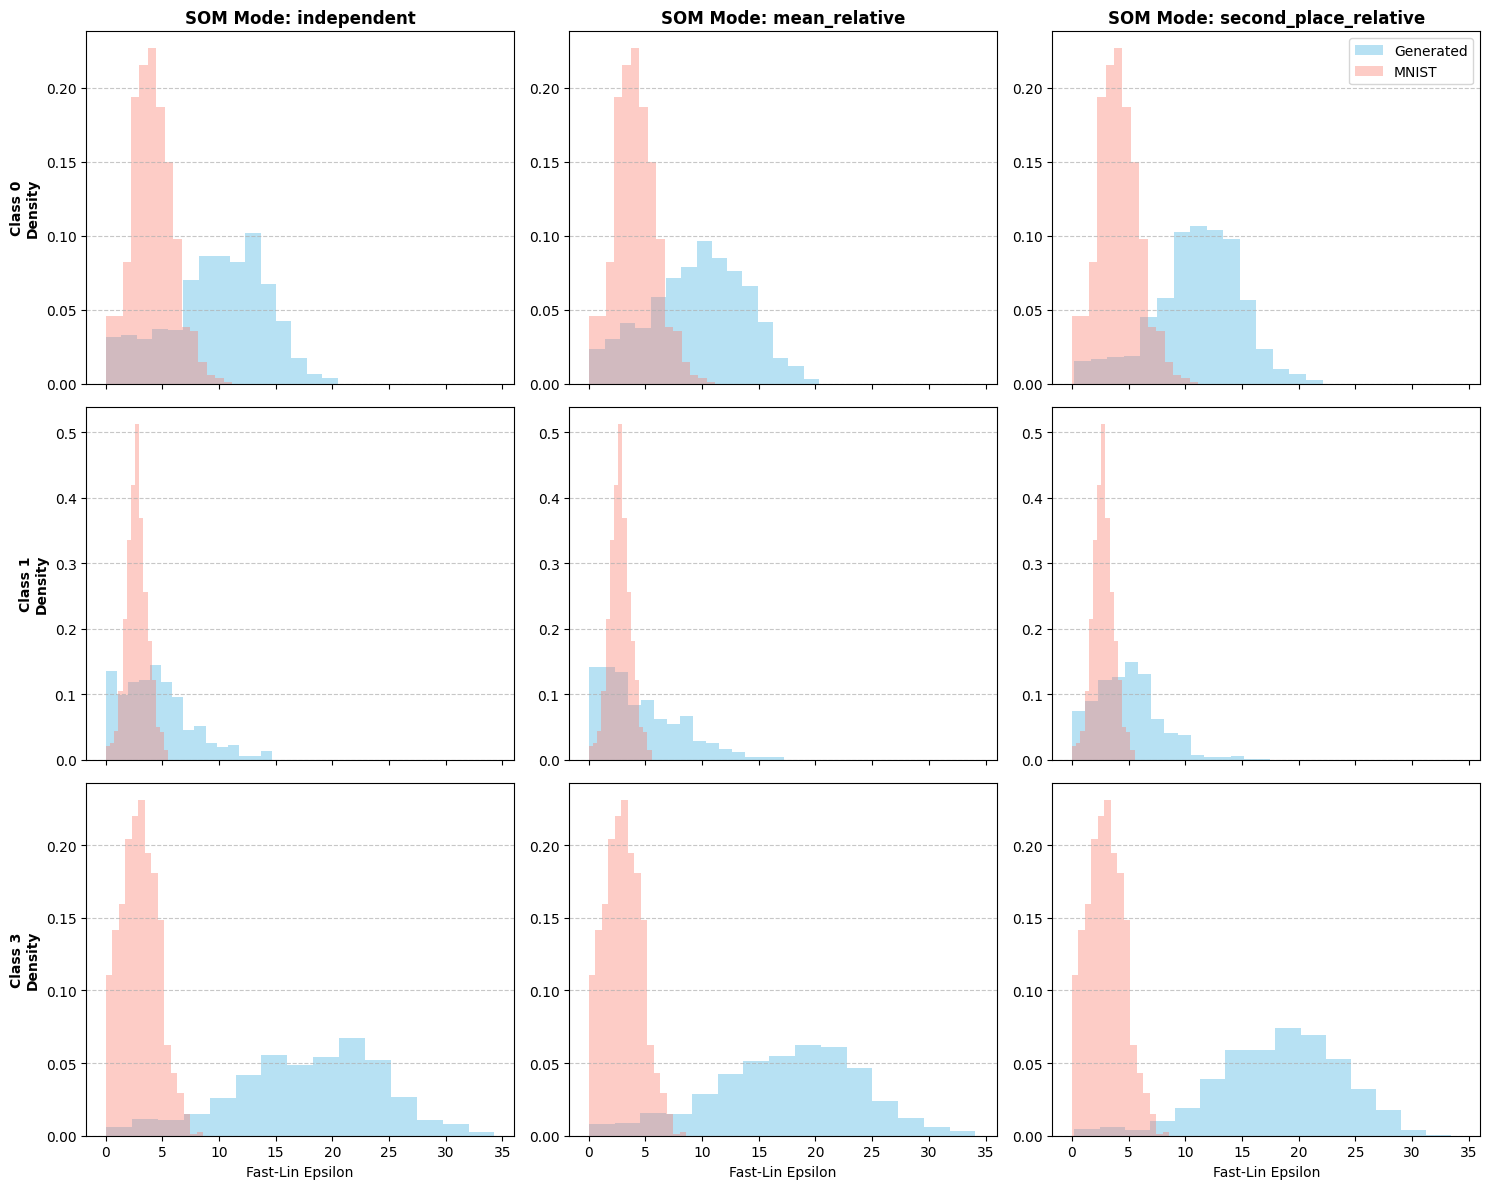

In [6]:
modes = sorted(df_exp2_fast['som_mode'].unique())
classes = sorted(df_exp2_fast['target_class'].unique())
n_rows, n_cols = len(classes), len(modes)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), sharex=True)
if n_rows == 1 or n_cols == 1: axes = np.array(axes).reshape(n_rows, n_cols)

for row_idx, cls in enumerate(classes):
    for col_idx, mode in enumerate(modes):
        ax = axes[row_idx, col_idx]
        gen_data = df_exp2_fast[(df_exp2_fast['target_class'] == cls) & (df_exp2_fast['som_mode'] == mode)]['fastlin_eps']
        mnist_data = df_exp1[df_exp1['label'] == cls]['epsilon']
        
        if not gen_data.empty: ax.hist(gen_data, bins=15, alpha=0.6, color='skyblue', label='Generated', density=True)
        if not mnist_data.empty: ax.hist(mnist_data, bins=15, alpha=0.4, color='salmon', label='MNIST', density=True)
        
        if row_idx == 0: ax.set_title(f"SOM Mode: {mode}", fontweight='bold')
        if col_idx == 0: ax.set_ylabel(f"Class {cls}\nDensity", fontweight='bold')
        if row_idx == n_rows - 1: ax.set_xlabel("Fast-Lin Epsilon")
        if row_idx == 0 and col_idx == n_cols - 1: ax.legend()
        ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Bar diagram comparison

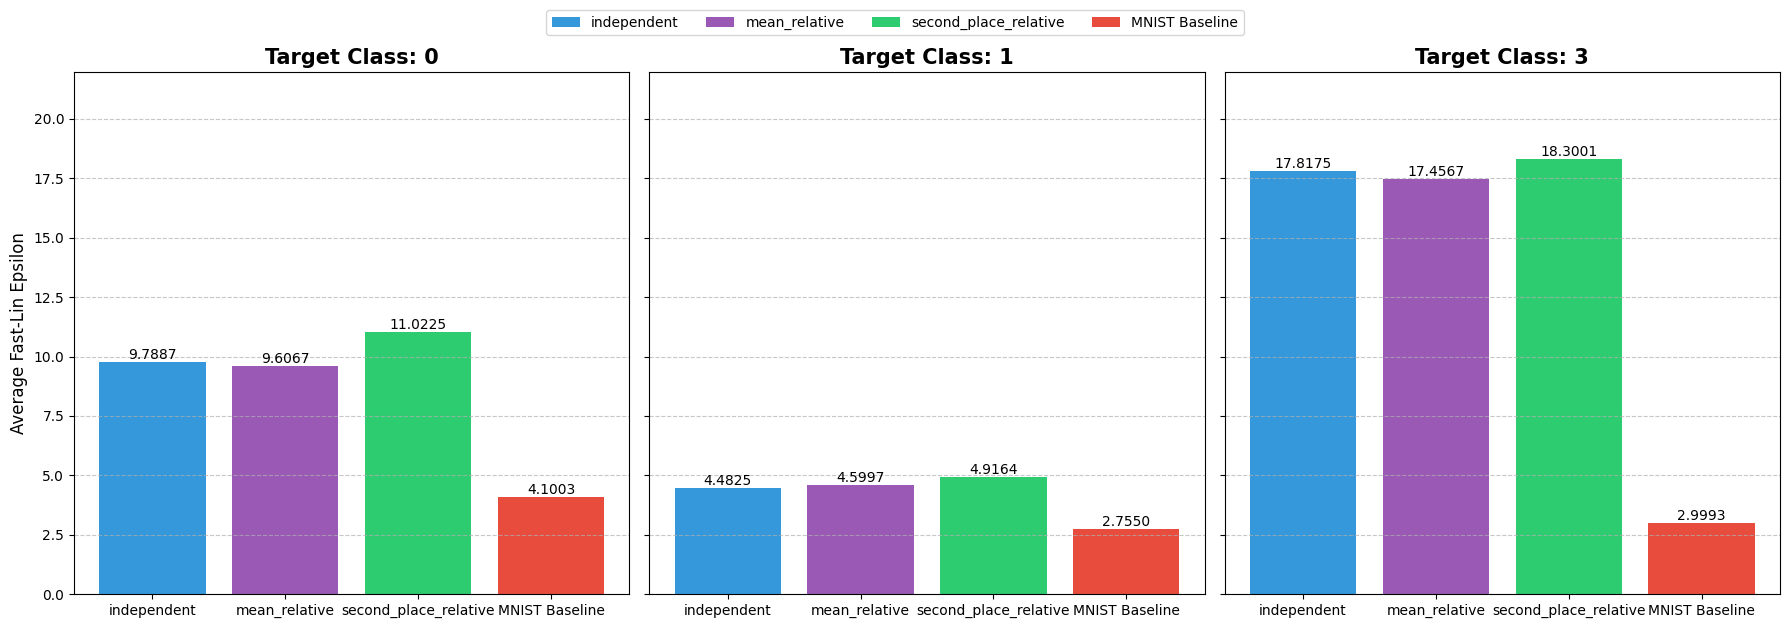

In [ ]:
# --- Method Comparison per Class (Sample Classes) ---
# This plot compares the average robustness of generated samples (by mode) against the MNIST baseline

# 1. Prepare the data
# Calculate mean robustness per class and mode for Experiment 2
gen_summary = df_exp2_fast.groupby(['target_class', 'som_mode'])['fastlin_eps'].mean().unstack()

# Calculate mean robustness per class for Experiment 1 (MNIST baseline)
mnist_summary = df_exp1.groupby('label')['epsilon'].mean()

# 2. Identify classes and modes to plot
plot_classes = sorted(df_exp2_fast['target_class'].unique())[:3]
modes = sorted(df_exp2_fast['som_mode'].unique())

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

# Define distinct colors for modes and the baseline
COLORS = ['#3498db', '#9b59b6', '#2ecc71', '#e74c3c'] 

for i, cls in enumerate(plot_classes):
    ax = axes[i]
    
    # Get values for this class: 3 generated modes + 1 baseline
    if cls in gen_summary.index:
        gen_vals = [gen_summary.loc[cls, m] if m in gen_summary.columns else 0 for m in modes]
    else:
        gen_vals = [0] * len(modes)
        
    mnist_val = mnist_summary.get(cls, 0)
    
    all_vals = gen_vals + [mnist_val]
    labels = modes + ['MNIST Baseline']
    
    # Create the bars
    bars = ax.bar(labels, all_vals, color=COLORS[:len(all_vals)])
    
    # Styling
    ax.set_title(f"Target Class: {cls}", fontsize=15, fontweight='bold')
    ax.set_ylabel("Average Fast-Lin Epsilon" if i == 0 else "", fontsize=12)
    ax.set_ylim(0, max(all_vals) * 1.2 if all_vals else 1)
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Add value labels on top of bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.002,
                f'{height:.4f}', ha='center', va='bottom', fontsize=10)

# Shared legend for the figure
fig.legend(bars, labels, loc='upper center', bbox_to_anchor=(0.5, 1.05), 
           ncol=len(labels), fontsize='medium')

plt.tight_layout()
#plt.savefig("Exp2_Robustness_Bar_Comparison.png", bbox_inches='tight')
plt.show()

## Approximation Quality: Fast-Lin vs. Exact Solver

<>:21: SyntaxWarning: invalid escape sequence '\e'
<>:21: SyntaxWarning: invalid escape sequence '\e'
C:\Users\adaml\AppData\Local\Temp\ipykernel_2716\1910228588.py:21: SyntaxWarning: invalid escape sequence '\e'
  plt.xlabel("Gap (Exact $\epsilon$ - Fast-Lin $\epsilon$)")


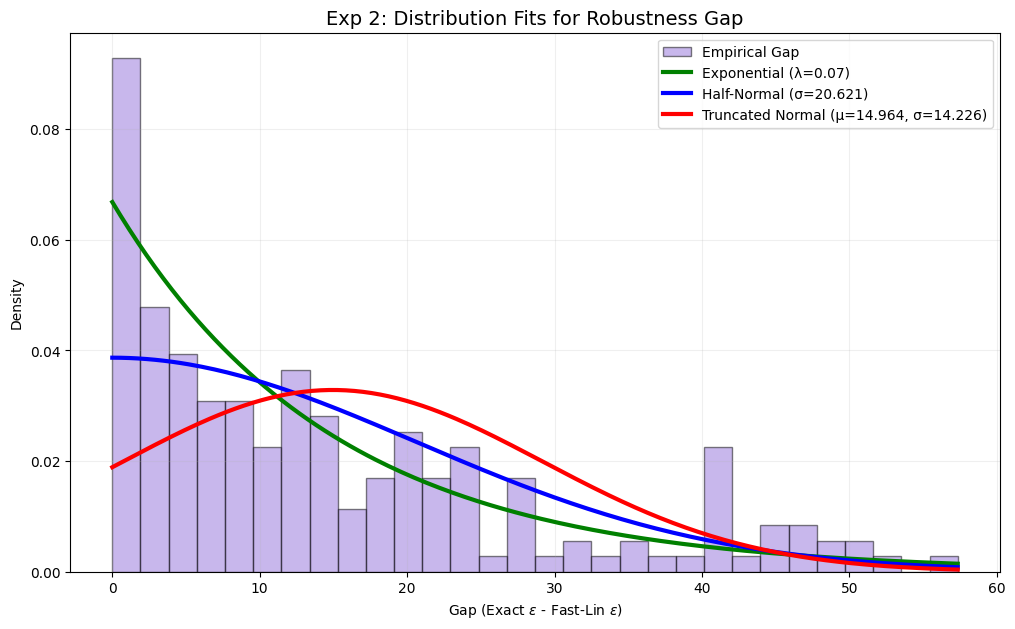

--- Fit Summary ---
Mean Gap: 14.963896
Correlation (R): 0.965253 (p=3.49e-109)

Full Covariance Matrix:
[[ 57.82357791 157.27016332]
 [157.27016332 459.09817921]]


In [5]:
if df_merged.empty:
    print("No exact results found to compare. Run the Exact Robustness cell first.")
else:
    data = df_merged['gap'].dropna()
    plt.figure(figsize=(12, 7))
    plt.hist(data, bins=30, color='mediumpurple', edgecolor='black', alpha=0.5, density=True, label="Empirical Gap")
    x = np.linspace(0, data.max(), 200)

    # Fits
    loc_ex, scale_ex = stats.expon.fit(data, floc=0)
    plt.plot(x, stats.expon.pdf(x, loc_ex, scale_ex), color='green', lw=3, label=f'Exponential (λ={1/scale_ex:.2f})')
    
    loc_hn, scale_hn = stats.halfnorm.fit(data)
    plt.plot(x, stats.halfnorm.pdf(x, loc_hn, scale_hn), color='blue', lw=3, label=f'Half-Normal (σ={scale_hn:.3f})')

    mu_guess, std_guess = data.mean(), data.std()
    a_bound = (0 - mu_guess) / std_guess
    plt.plot(x, stats.truncnorm.pdf(x, a_bound, np.inf, loc=mu_guess, scale=std_guess), color='red', lw=3, label=f'Truncated Normal (μ={mu_guess:.3f}, σ={std_guess:.3f})')

    plt.title("Exp 2: Distribution Fits for Robustness Gap", fontsize=14)
    plt.xlabel("Gap (Exact $\epsilon$ - Fast-Lin $\epsilon$)")
    plt.ylabel("Density")
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()

    # Covariance & Correlation
    cov_matrix = np.cov(df_merged['epsilon_fast'], df_merged['epsilon_exact'])
    r_val, p_val = stats.pearsonr(df_merged['epsilon_fast'], df_merged['epsilon_exact'])

    print(f"--- Fit Summary ---")
    print(f"Mean Gap: {data.mean():.6f}")
    print(f"Correlation (R): {r_val:.6f} (p={p_val:.2e})")
    print("\nFull Covariance Matrix:")
    print(cov_matrix)

## Robustness transferbility

### Class-wise bar-diagram comparison

<>:43: SyntaxWarning: invalid escape sequence '\e'
<>:43: SyntaxWarning: invalid escape sequence '\e'
C:\Users\adaml\AppData\Local\Temp\ipykernel_14556\18678095.py:43: SyntaxWarning: invalid escape sequence '\e'
  ax.set_ylabel('Average Fast-Lin Epsilon ($\epsilon$)', fontsize=12)


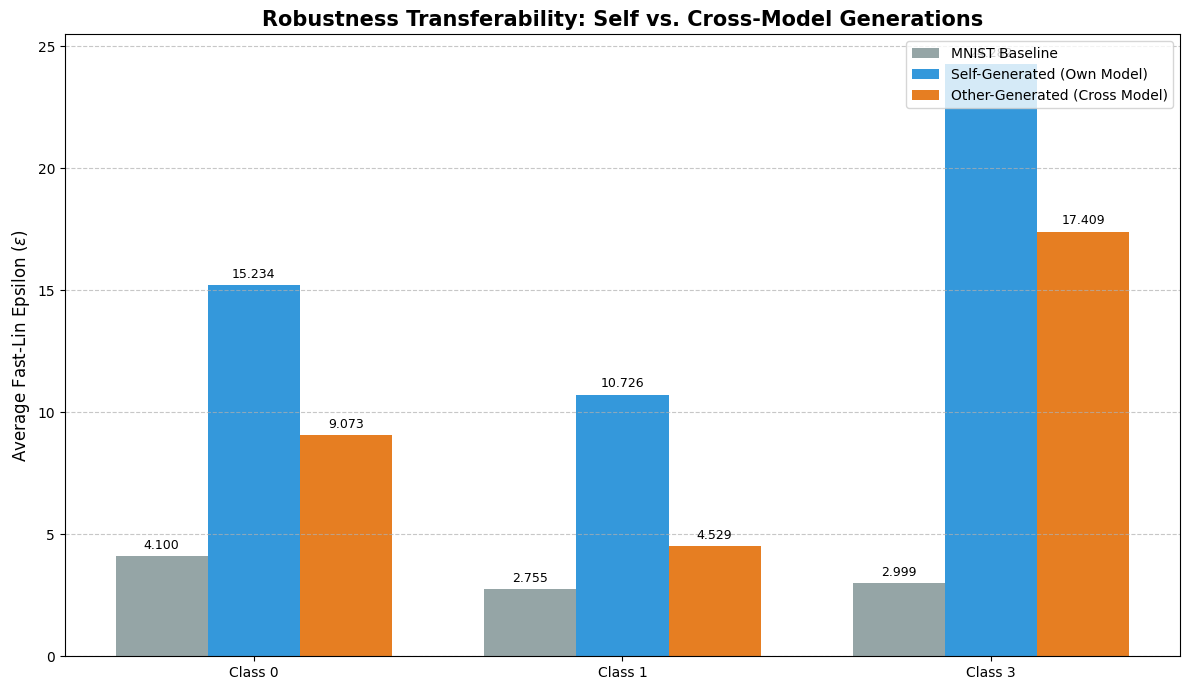

In [ ]:
# --- Transferability Detail (Self vs. Cross-Model) ---

# 1. Load the data
df_exp1 = pd.read_csv("results/Exp1FastLinRobustnessResults.csv") 
df_exp2 = pd.read_csv("results/Exp2FastLinOnGeneratedSamples.csv")

# 2. Calculate MNIST Baseline (Average epsilon per class across all networks)
mnist_means = df_exp1.groupby('label')['epsilon'].mean()

# 3. Process Experiment 2 for Self vs. Other
# 'Self' is identified when the testing network is the same as the generating network
df_exp2['is_self'] = df_exp2['testing_network'] == df_exp2['generating_network']

# Calculate averages for Self and Cross-model generations
self_means = df_exp2[df_exp2['is_self']].groupby('target_class')['fastlin_eps'].mean()
other_means = df_exp2[~df_exp2['is_self']].groupby('target_class')['fastlin_eps'].mean()

# 4. Align the data by target classes
target_classes = sorted(df_exp2['target_class'].unique())

final_data = []
for cls in target_classes:
    final_data.append({
        'Class': f"Class {cls}",
        'MNIST Baseline': mnist_means.get(cls, 0),
        'Self-Generated': self_means.get(cls, 0),
        'Other-Generated': other_means.get(cls, 0)
    })

plot_df = pd.DataFrame(final_data).set_index('Class')

# 5. Plotting
x = np.arange(len(target_classes))
width = 0.25  # Width of each grouped bar

fig, ax = plt.subplots(figsize=(12, 7))

rects1 = ax.bar(x - width, plot_df['MNIST Baseline'], width, label='MNIST Baseline', color='#95a5a6')
rects2 = ax.bar(x, plot_df['Self-Generated'], width, label='Self-Generated (Own Model)', color='#3498db')
rects3 = ax.bar(x + width, plot_df['Other-Generated'], width, label='Other-Generated (Cross Model)', color='#e67e22')

# Styling
ax.set_ylabel('Average Fast-Lin Epsilon ($\epsilon$)', fontsize=12)
ax.set_title('Robustness Transferability: Self vs. Cross-Model Generations', fontsize=15, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(plot_df.index)
ax.legend(fontsize='medium', loc='upper right')
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Helper function to add value labels on top of bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        if height > 0:
            ax.annotate(f'{height:.3f}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3),  # 3 points vertical offset
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=9)

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

plt.tight_layout()
#plt.savefig("Exp2_Self_vs_Cross_Robustness.png")
plt.show()

### SOM-mode bar-diagram comparison

<>:25: SyntaxWarning: invalid escape sequence '\e'
<>:25: SyntaxWarning: invalid escape sequence '\e'
C:\Users\adaml\AppData\Local\Temp\ipykernel_14556\3756301219.py:25: SyntaxWarning: invalid escape sequence '\e'
  ax.set_ylabel('Average Fast-Lin Epsilon ($\epsilon$)', fontweight='bold')


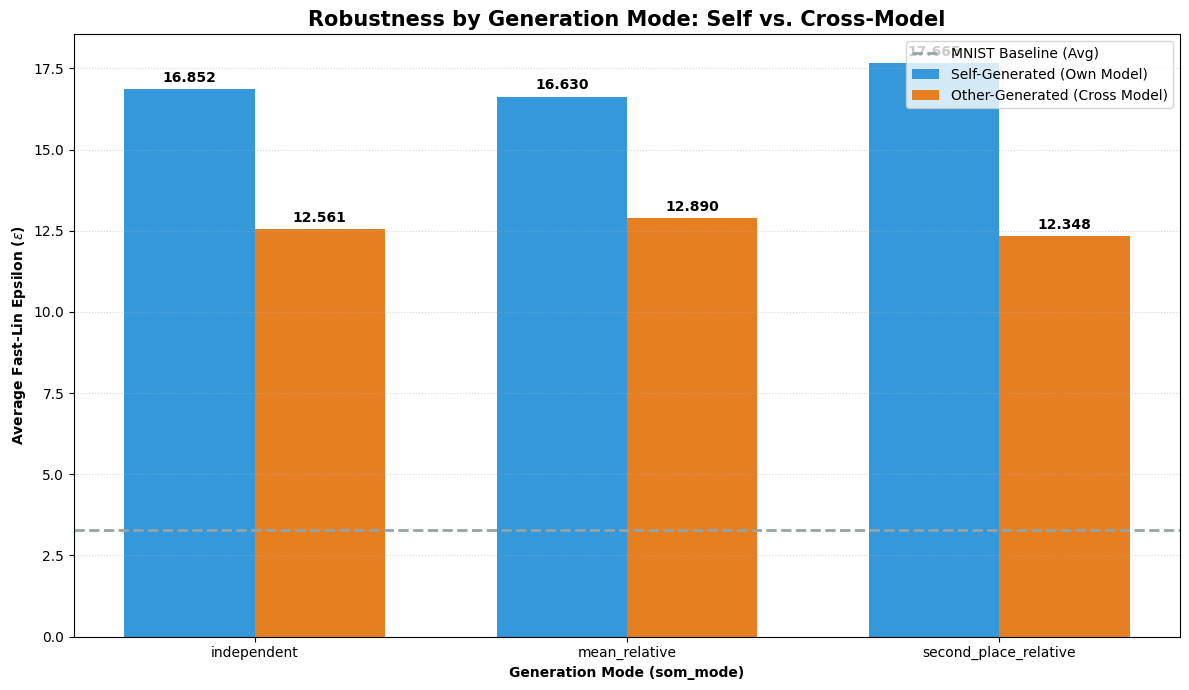

In [10]:
# A. Calculate Baselines and Groupings
mnist_baseline_avg = df_exp1['epsilon'].mean()
modes = sorted(df_exp2_fast['som_mode'].unique())

mode_data = []
for mode in modes:
    subset = df_exp2_fast[df_exp2_fast['som_mode'] == mode]
    mode_data.append({
        'Mode': mode,
        'Self-Generated': subset[subset['is_self']]['fastlin_eps'].mean(),
        'Other-Generated': subset[~subset['is_self']]['fastlin_eps'].mean()
    })

plot_df = pd.DataFrame(mode_data).set_index('Mode')

# B. Plotting
x = np.arange(len(modes))
width = 0.35
fig, ax = plt.subplots(figsize=(12, 7))

rects1 = ax.bar(x - width/2, plot_df['Self-Generated'], width, label='Self-Generated (Own Model)', color='#3498db')
rects2 = ax.bar(x + width/2, plot_df['Other-Generated'], width, label='Other-Generated (Cross Model)', color='#e67e22')
ax.axhline(y=mnist_baseline_avg, color='#95a5a6', linestyle='--', lw=2, label='MNIST Baseline (Avg)')

ax.set_ylabel('Average Fast-Lin Epsilon ($\epsilon$)', fontweight='bold')
ax.set_xlabel('Generation Mode (som_mode)', fontweight='bold')
ax.set_title('Robustness by Generation Mode: Self vs. Cross-Model', fontsize=15, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(modes)
ax.legend()
ax.grid(axis='y', linestyle=':', alpha=0.5)

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}', xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontweight='bold')

autolabel(rects1)
autolabel(rects2)
plt.tight_layout()
plt.show()

## Scatter-plot analysis of possible factors of robustness transferability

<>:16: SyntaxWarning: invalid escape sequence '\e'
<>:16: SyntaxWarning: invalid escape sequence '\e'
C:\Users\adaml\AppData\Local\Temp\ipykernel_18752\3175364120.py:16: SyntaxWarning: invalid escape sequence '\e'
  ax.set_ylabel("Victim Robustness (Fast-Lin $\epsilon$)", fontweight='bold')


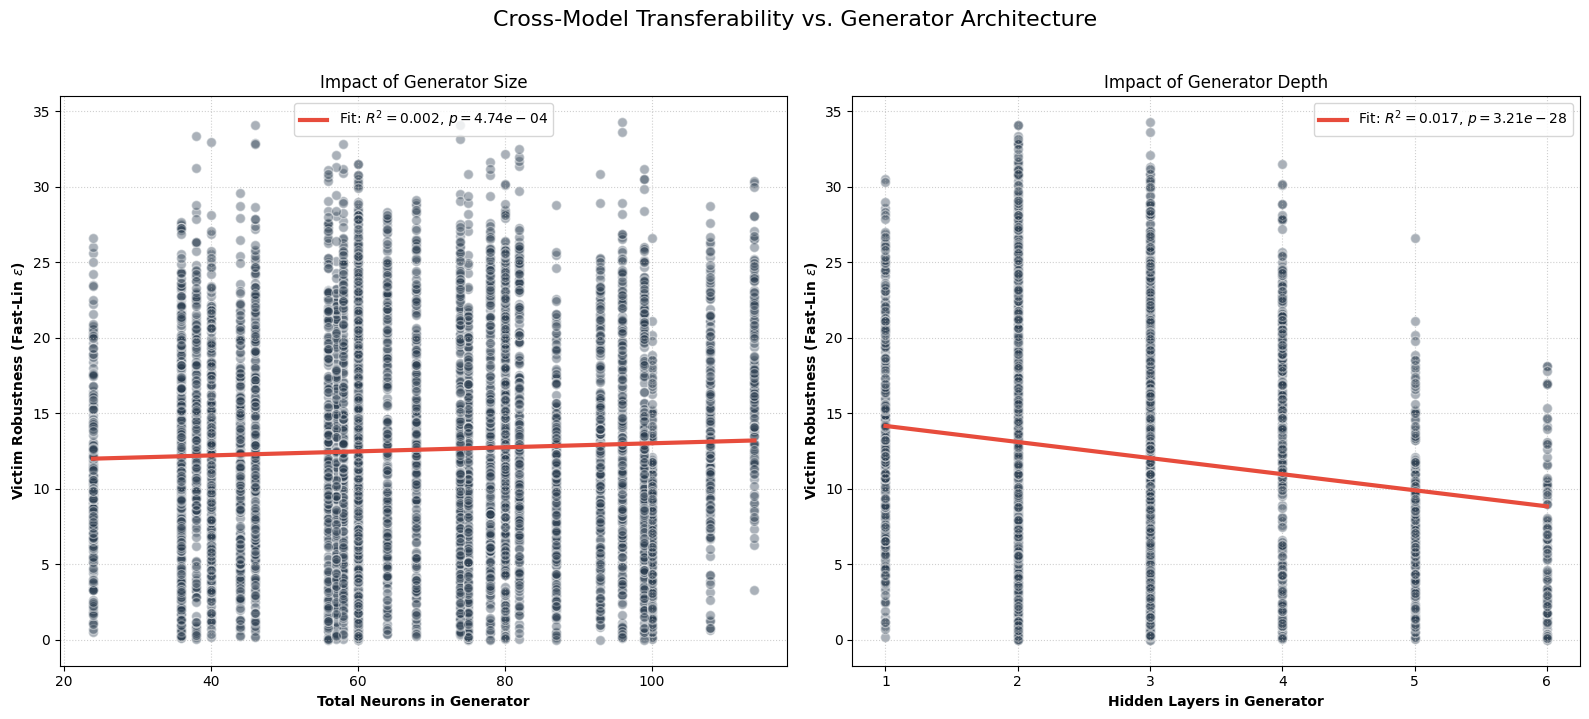

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

def plot_arch_impact(ax, x_col, xlabel, title):
    x_data = df_cross[x_col].values
    y_data = df_cross['fastlin_eps'].values
    ax.scatter(x_data, y_data, alpha=0.4, color='#2c3e50', edgecolors='white', s=50)
    
    if len(np.unique(x_data)) > 1:
        slope, intercept, r_val, p_val, _ = stats.linregress(x_data, y_data)
        x_range = np.linspace(x_data.min(), x_data.max(), 100)
        p_str = f"{p_val:.2e}" if p_val < 0.001 else f"{p_val:.4f}"
        ax.plot(x_range, slope * x_range + intercept, color='#e74c3c', lw=3,
                label=f'Fit: $R^2={r_val**2:.3f}$, $p={p_str}$')
    
    ax.set_xlabel(xlabel, fontweight='bold')
    ax.set_ylabel("Victim Robustness (Fast-Lin $\epsilon$)", fontweight='bold')
    ax.set_title(title)
    ax.legend()
    ax.grid(True, linestyle=':', alpha=0.6)

plot_arch_impact(ax1, 'gen_neurons', "Total Neurons in Generator", "Impact of Generator Size")
plot_arch_impact(ax2, 'gen_layers', "Hidden Layers in Generator", "Impact of Generator Depth")
plt.suptitle("Cross-Model Transferability vs. Generator Architecture", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()